# Task 1: Barebone Deep Neural Network

The background, notation, and full instructions for this task are in the **HW2 assignment PDF** (Task 1).

Complete the `# TODO-n` cells below, and run the check cells that follow them to verify your work.

## What we will build

A **deep neural network** is not one big, complicated function; it is a **chain of simple blocks**, where each block's output becomes the next block's input. A typical network looks like this:

```
input  →  linear  →  ReLU  →  linear  →  ReLU  →  …  →  linear  →  output
```

The **linear** blocks mix the numbers together ($z=\theta_1x+\theta_0$), and the **ReLU** blocks ($a(z)$) bend them (the nonlinearity that lets the network capture non-linear relationships). We add one more block onto the end, the **loss** $(\hat{y}-y)$, which measures how wrong the prediction is.

If we think of each block as a **Lego brick**.

- a **forward pass** turns the brick's input into its output, and
- a **backward pass** computes the *gradients* (derivatives): how much the loss would change if the brick's input or its parameters changed. These gradients are what let the network learn.

**Step 1: build the bricks.** First you implement each brick on its own, writing both its forward and its backward pass:

1. **Linear layer** (forward + backward): the weighted sum $x\,W^{\top} + b$.
2. **ReLU activation** (forward + backward): the nonlinearity $\max(0,\ z)$.
3. **Loss (MSE)** (forward + backward): how far the predictions are from the targets.

**Step 2: snap the bricks together.** Then we chain the bricks into a working network:

- **Gradient descent** uses the gradients to nudge each parameter a little in the right direction.
- **Build the network** stacks linear and ReLU bricks into a multi-layer network.
- **Forward and backward through the whole network** runs the bricks in order to make a prediction, then in reverse to collect every gradient.
- **Train** repeats: predict, measure the loss, backpropagate, and update, until the network fits the data.

Once each brick is correct, building the full network is just a matter of clicking them together, exactly as you will see in section 5.

## 1  Linear layer
### 1.1 Linear forward  `TODO-1`

A linear (fully connected) layer turns each input into a weighted sum plus a bias. For a **single** sample $x$ (a row of `in_dim` numbers), the layer computes the **pre-activation** output

$$
z \;=\; x\,W^{\top} + b ,
$$

where $W$ (shape $\text{out\_dim}\times\text{in\_dim}$) holds one row of weights per output unit, $b$ (length $\text{out\_dim}$) holds one bias per output unit, and $z$ has length $\text{out\_dim}$. In code we process the whole batch at once: `x` has one row per sample, and the same bias `b` is added to every row.

| Name | Meaning | Shape |
|------|---------|-------|
| `x` | batch of inputs (one row per sample) | $(B,\ \text{in\_dim})$ |
| `W` | weights | $(\text{out\_dim},\ \text{in\_dim})$ |
| `b` | biases | $(\text{out\_dim})$ |
| `z` | pre-activation output | $(B,\ \text{out\_dim})$ |

**Your job (`TODO-1`):** compute `z` from `x`, `W`, and `b`.

> `initialize_linear_layer` is already written for you: it creates `W`, `b`, and empty gradient slots (`dW`, `db`) using *He initialization*. You do not need to change it.

In [ ]:
import numpy as np

def linear_forward(x, params):
    W, b = params["W"], params["b"]

    # TODO-1: implement forward linear pass
    # === Your code here ===
    z = ...
    # === Your code end ===

    cache = (x, params)
    return z, cache


def initialize_linear_layer(input_dim, output_dim):
    # He initialization; dW and db start at zero (filled in during backprop)
    return {
        "W": np.random.randn(output_dim, input_dim) * (2 / input_dim) ** 0.5,
        "b": np.zeros(output_dim),
        "dW": np.zeros((output_dim, input_dim)),
        "db": np.zeros(output_dim),
    }

**Check cell.** Run the next cell to verify your `linear_forward`; it should print a ✅.

In [ ]:
# === Check for TODO-1: linear_forward ===
#
#  Tests your implementation using a 2x3 input and a 2x3 weight matrix.

# Input matrix: shape (batch_size=2, input_dim=3)
x_test = np.array([
    [1.0, 2.0, 3.0],
    [0.5, -1.0, 2.0]
])

# Parameters:
# W has shape (output_dim=2, input_dim=3)
# b has shape (output_dim=2,)
params_test = {
    "W": np.array([
        [0.1, 0.2, 0.3],
        [-0.5, 0.0, 0.5]
    ]),
    "b": np.array([0.1, -0.2])
}

# Resulting shape: (2, 2)
expected_z = np.array([
    [1.5, 0.8],
    [0.55, 0.55]
])

# Run student code
z_out, _ = linear_forward(x_test, params_test)

# Check
assert np.allclose(z_out, expected_z), f"Incorrect result.\nGot:\n{z_out}\nExpected:\n{expected_z}"
print("✅ linear_forward passed the 2x3 input test.")


### 1.2 Linear backward  `TODO-2`

**Recall the forward pass.** This layer computed its output from the input $x$, the weights $W$, and the biases $b$:
$$
z \;=\; x\,W^{\top} + b .
$$

**What the backward pass receives.** By the time we reach this layer while going backward, the layers *after* it have already computed how much the loss $L$ changes when this layer's output $z$ changes. We are handed that signal, called `dz`:
$$
dz \;=\; \frac{\partial L}{\partial z},
$$
which has exactly the same shape as $z$, namely $(B,\ \text{out\_dim})$, with one row per sample.

**What we must produce.** Using `dz` together with the values cached during the forward pass ($x$ and $W$), we compute three gradients:

| Name | Meaning | Used for | Shape |
|------|---------|----------|-------|
| `dz` | $\partial L/\partial z$, the gradient handed to us | (input) | $(B,\ \text{out\_dim})$ |
| `dW` | $\partial L/\partial W$ | updating the weights | $(\text{out\_dim},\ \text{in\_dim})$ |
| `db` | $\partial L/\partial b$ | updating the biases | $(\text{out\_dim})$ |
| `dx` | $\partial L/\partial x$ | passing the gradient back to the previous layer | $(B,\ \text{in\_dim})$ |

The diagram below shows this flow: the loss signal enters at $z$ and splits toward $W$, $b$, and $x$.

<div style="text-align: center;">
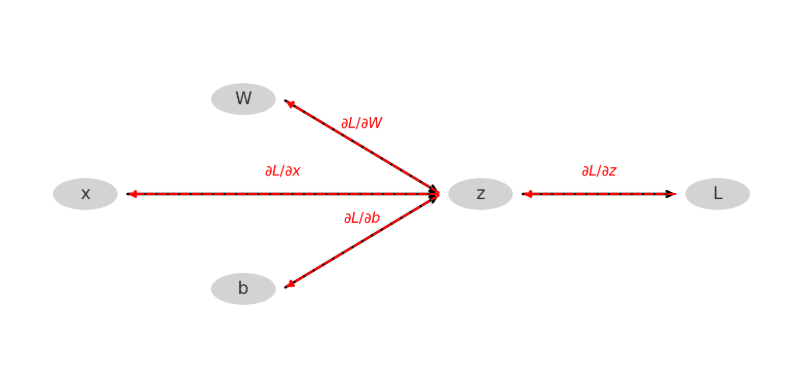
</div>

**Derivation.** Each gradient follows from the chain rule applied to $z = x\,W^{\top} + b$.

**Weights $W$.** In the forward pass each weight multiplies an input, so the input tells us how sensitive $z$ is to $W$. The chain rule combines `dz` with the input `x`, summed over the batch:
$$
\frac{\partial L}{\partial W} \;=\; (dz)^{\top} x .
$$

**Biases $b$.** The bias is *added* to $z$, so changing $b$ changes $z$ one for one. The bias gradient is `dz` summed over the samples:
$$
\frac{\partial L}{\partial b} \;=\; \sum_{i=1}^{B} dz_i .
$$

**Input $x$.** The input reaches $z$ only through the weights $W$, so the chain rule sends the gradient back through $W$:
$$
\frac{\partial L}{\partial x} \;=\; dz\,W .
$$

**Your job (`TODO-2`).** Compute `dW`, `db`, and `dx` from these three formulas.

**Hints**

- Use `.T` to transpose so the shapes in the table above line up.
- Do **not** add a $1/B$ factor: the loss already averaged (it divided by $N$), so that scaling is already inside `dz`. `dW` and `db` are plain sums over the batch, and `dx` just carries the gradient back to the previous layer.

In [ ]:
def linear_backward(dz, cache):
    x, params = cache
    W = params["W"]

    # TODO-2: compute gradients
    # === Your code here ===
    dW = ...
    db = ...
    dx = ...
    # === Your code end ===

    params["dW"] = dW
    params["db"] = db
    return dx

**Check cell.** Run the next cell to verify your `linear_backward` against PyTorch autograd; it should print a ✅.

In [ ]:
import torch, numpy as np

B, in_dim, out_dim = 4, 5, 3

x_t = torch.randn(B, in_dim,  requires_grad=True)
W_t = torch.randn(out_dim, in_dim, requires_grad=True)
b_t = torch.randn(out_dim,      requires_grad=True)

# Forward + backward in PyTorch (loss = SUM, not mean)
z_t   = x_t @ W_t.T + b_t
loss  = z_t.sum()                # ∂L/∂z = 1
loss.backward()

# Build NumPy copies
x   = x_t.detach().numpy()
W   = W_t.detach().numpy()
b   = b_t.detach().numpy()
dz  = np.ones_like(z_t.detach().numpy())    # upstream gradient = 1  (matches loss = sum)

params = {"W": W.copy(),
          "b": b.copy(),
          "dW": np.zeros_like(W),
          "db": np.zeros_like(b)}
cache  = (x, params)


# Compare 
dx = linear_backward(dz, cache)
np.testing.assert_allclose(params["dW"], W_t.grad.numpy(), rtol=1e-5)
np.testing.assert_allclose(params["db"], b_t.grad.numpy(), rtol=1e-5)
np.testing.assert_allclose(dx,            x_t.grad.numpy(),     rtol=1e-5)

print("✅ linear_backward passes autograd test with your current implementation.")

## 2  ReLU activation

After each linear layer we apply a nonlinearity. We use **ReLU (Rectified Linear Unit)**, applied to every number on its own:

$$
\operatorname{ReLU}(z) = \max(0,\ z).
$$

Each number is kept if it is positive, or replaced by $0$ if it is negative. For example,

$$
Z=\begin{bmatrix}-1.2 & 0.0 & 3.4\\ 2.1 & -0.5 & 1.3\end{bmatrix}
\quad\longrightarrow\quad
\operatorname{ReLU}(Z)=\begin{bmatrix}0.0 & 0.0 & 3.4\\ 2.1 & 0.0 & 1.3\end{bmatrix}.
$$

**Backward.** The derivative of ReLU is $1$ where the input was positive and $0$ otherwise:

$$
\frac{\partial\,\operatorname{ReLU}(z)}{\partial z} =
\begin{cases}1 & z>0\\[2pt] 0 & z\le 0.\end{cases}
$$

So the backward pass keeps the incoming gradient where the (cached) input was positive, and sets it to $0$ everywhere else.

**Your job:** `relu_forward` (`TODO-3`): return $\operatorname{ReLU}(z)$. &nbsp; `relu_backward` (`TODO-4`): mask the incoming gradient `dz` using the positions where the input was positive.

In [ ]:
def relu_forward(z):
    # TODO-3: implement forward ReLU pass
    # === Your code here ===
    out = ...  # element-wise ReLU
    # === Your code end ===

    return out, z            # cache the raw input


def relu_backward(dout, z):
    dz = dout.copy()         # keep upstream gradient
    # TODO-4: apply ReLU mask
    # === Your code here ===
    da = ...             # Hint: mask dz where z <= 0
    # === Your code end ===
    return da

**Check cell.** Run the next cell to verify your ReLU forward and backward; it should print ✅.

In [ ]:
# === Check for TODO-3 and TODO-4: ReLU forward / backward ===
import numpy as np

# Tiny 2×4 tensor with positive, zero, and negative entries
z_test = np.array([[ 1.0, -2.0,  0.0, 3.0],
                   [-1.5,  2.5, -0.3, 0.0]], dtype=float)

# ---------- Forward check ----------
out, cache = relu_forward(z_test)

expected_forward = np.array([[1.0, 0.0, 0.0, 3.0],
                             [0.0, 2.5, 0.0, 0.0]], dtype=float)

np.testing.assert_array_equal(out, expected_forward)
print("✅ ReLU forward passes simple mask test.")

# ---------- Backward check ----------
# Upstream gradient: ones, same shape
dout = np.ones_like(z_test)

grad = relu_backward(dout, cache)

# Should propagate 1 where z_test>0, else 0
expected_grad = np.array([[1.0, 0.0, 0.0, 1.0],
                          [0.0, 1.0, 0.0, 0.0]], dtype=float)

np.testing.assert_array_equal(grad, expected_grad)
print("✅ ReLU backward passes simple mask test.")


## 3  Loss: mean-squared error (MSE)

The loss is a single number that measures how far the predictions $\hat y$ are from the targets $y$. We use the **mean-squared error**: square every difference, then take the average.

Writing $\hat y_k$ and $y_k$ for the $N$ predicted numbers and their targets (counting every sample and every output), the loss is the average of the squared differences:

$$
L \;=\; \frac{1}{N}\sum_{k=1}^{N}\big(\hat y_k - y_k\big)^2 .
$$

In code, the differences are the residuals $\text{diff} = \hat y - y$, and $L$ is the mean of $\text{diff}^2$.

**Forward (`TODO-5`).** Compute the residuals `diff` and the scalar loss `loss`, and return both (keep `diff` for the backward step).

**Backward (`TODO-6`).** To learn, we need the gradient of the loss with respect to the predictions. Differentiating $L$ gives

$$
g \;=\; \frac{\partial L}{\partial \hat y} \;=\; \frac{2}{N}\,(\hat y - y) \;=\; \frac{2}{N}\,\text{diff},
$$

that is, scale the residuals by $2/N$, where $N$ is the total number of predicted values (`diff.size`).

| Name | Meaning | Shape |
|------|---------|-------|
| `y_hat` | predictions | $(B,\ d)$ |
| `y` | targets | $(B,\ d)$ |
| `diff` | residuals $\hat y - y$ | $(B,\ d)$ |
| `loss` | MSE (a single number) | scalar |
| `g` | gradient of the loss w.r.t. the predictions | $(B,\ d)$ |

In [ ]:
def mse_forward(y_hat, y):
    # TODO-5: compute mean squared error loss
    # === Your code here ===
    diff = ...                  # (B, d)
    loss = ...         # scalar
    # === Your code end ===
    return loss, diff


def mse_backward(diff):
    n = diff.size          # total number of predicted values (all samples and outputs)

    # TODO-6: compute gradient of the loss w.r.t. y_hat
    # === Your code here ===
    g = ...
    # === Your code end ===
    return g

**Check cell.** Run the next cell to verify your MSE forward and backward; it should print ✅.

In [ ]:
# Tiny deterministic example
y_hat = np.array([[3.0, 2.0],
                  [1.0, 4.0]], dtype=float)   # (B=2, d=2)

y_true = np.array([[2.0, 0.0],
                   [1.0, 5.0]], dtype=float)

loss, diff = mse_forward(y_hat, y_true)

expected_diff  = np.array([[ 1.0,  2.0],
                           [ 0.0, -1.0]], dtype=float)

expected_loss  = ((expected_diff**2).mean())  

np.testing.assert_array_equal(diff, expected_diff)
np.testing.assert_allclose(loss, expected_loss, rtol=1e-12)
print("✅ mse_forward produces correct residuals and loss.")

grad = mse_backward(diff)

expected_grad = 2 * expected_diff / expected_diff.size   # = [[0.5, 1.0], [0.0, -0.5]]

np.testing.assert_array_equal(grad, expected_grad)
print("✅ mse_backward returns correct gradient.")

## 4  Gradient descent (parameter update)

After backprop, every layer holds its gradients `dW` and `db`. Gradient descent nudges each parameter a small step **downhill** (opposite its gradient) with a step size set by the learning rate $\eta$ (`lr`):

$$
W \leftarrow W - \eta\,dW, \qquad b \leftarrow b - \eta\,db.
$$

**Your job (`TODO-7`):** update each layer's `W` and `b` using this rule.

`zero_grads` (already written) then resets all gradients to zero so the next batch starts fresh; otherwise gradients from different batches would pile up.

| Name | Meaning |
|------|---------|
| `param_list` | all layers' parameters (`W`, `b`, and their gradients `dW`, `db`) |
| `lr` | learning rate $\eta$ (a single number setting the step size) |

In [ ]:
def sgd_step(param_list, lr):
    for p in param_list:
        W = p["W"]
        dw = p["dW"]
        b = p["b"]
        db = p["db"]

        # TODO-7: implement SGD step
        # === Your code here ===
        W = ...
        b = ...
        # === Your code end ===

        p["W"] = W            # update weight
        p["b"] = b            # update bias

def zero_grads(param_list):
    for params in param_list:
        params["dW"].fill(0)
        params["db"].fill(0)

## 5  Build the network

`build_network` (already written) stacks the pieces into a multi-layer network. Given the input size, a list of hidden-layer sizes, and the output size, it creates a **linear layer** for each consecutive pair of sizes and inserts a **ReLU** after every linear layer except the last. It returns two lists: `layers` (the ordered layers, used for the forward and backward passes) and `params` (just the trainable weights and biases, used for the updates).

**Example.** With `input_dim = 4`, `hidden_dims = [10, 5]`, and `output_dim = 2` (so `dims = [4, 10, 5, 2]`), it builds:

```
linear (4 → 10) → ReLU → linear (10 → 5) → ReLU → linear (5 → 2)
```

| Name | Meaning |
|------|---------|
| `input_dim` | number of input features |
| `hidden_dims` | list of hidden-layer sizes, e.g. `[10, 5]` |
| `output_dim` | number of outputs |
| `layers` | the ordered layers (linear and ReLU) |
| `params` | the trainable parameter sets (one per linear layer) |

In [ ]:
def build_network(input_dim, hidden_dims, output_dim):
    dims = [input_dim] + hidden_dims + [output_dim]
    layers, params = [], []
    for i in range(len(dims) - 1):
        p = initialize_linear_layer(dims[i], dims[i+1])
        layers.append(("linear", p))
        params.append(p)
        if i < len(dims) - 2:
            layers.append(("relu", None))
    return layers, params

## 6  Whole-network forward & backward

These two helpers (already written) chain together the per-layer functions you implemented:

- **`network_forward`** runs the input through every layer in order (linear → ReLU → …), saving each layer's `cache` so the gradients can be computed later. It returns the network's output and the list of caches.
- **`network_backward`** starts from the gradient at the output and walks the layers **in reverse**, calling each layer's backward function so that every layer's `dW` and `db` get filled in.

| Name | Meaning | Shape |
|------|---------|-------|
| `x` | batch of inputs | $(B,\ \text{in\_dim})$ |
| `output` | network predictions | $(B,\ \text{out\_dim})$ |
| `caches` | saved forward-pass values | n/a |
| `dout` | gradient at the output | $(B,\ \text{out\_dim})$ |

In [ ]:
def network_forward(x, layers):
    caches = []
    for layer_type, params in layers:
        if layer_type == "linear":
            x, cache = linear_forward(x, params)
        else:
            x, cache = relu_forward(x)
        caches.append((layer_type, cache))
    return x, caches

def network_backward(dout, caches):
    for layer_type, cache in reversed(caches):
        if layer_type == "linear":
            dout = linear_backward(dout, cache)
        else:
            dout = relu_backward(dout, cache)

## 7  Train the network

Finally, train the full network on a small **synthetic regression** task: `X` is random and the targets `Y` come from a fixed linear map, so a correct network should fit them almost perfectly.

Each **epoch** shuffles the data and then, for every mini-batch, runs one training step:

1. **forward**: predict with `network_forward`
2. **loss**: compare to the targets with `mse_forward`
3. **backward**: `mse_backward`, then `network_backward`
4. **update**: `sgd_step`
5. **reset**: `zero_grads`

**`TODO-8`:** choose the hyperparameters: learning rate, number of epochs, batch size, and the hidden-layer sizes.

**`TODO-9`:** write one training step: run the network forward to get the predictions and caches, then compute the loss and residuals (reuse `network_forward` and `mse_forward`).

When every TODO is correct, training drives the **final MSE below `1e-3`**.

In [ ]:
# Generate synthetic regression data
np.random.seed(42)          # reproducibility: seed NumPy so runs are repeatable
N, D, C = 20, 5, 3
X = np.random.randn(N, D)
true_W = np.random.randn(C, D)
Y = X @ true_W.T

# TODO-8: set hyperparameters
# === Your code here ===
lr, epochs = ...
batch_size = ...
hidden_dimensions = [...]  # Example hidden layer size, can be a list like [1,2,3,...]
# === Your code end ===

# Build the Deep Neural Network
layers, params = build_network(D, hidden_dimensions, C)

for ep in range(epochs):
    # Shuffle data
    indices = np.random.permutation(N)
    X_shuffled, Y_shuffled = X[indices], Y[indices]

    for i in range(0, N, batch_size):
        x_batch = X_shuffled[i:i+batch_size]
        y_batch = Y_shuffled[i:i+batch_size]

        # TODO-9: forward pass, loss computation (use previously defined functions)
        # === Your code here ===
        y_hat, caches = ...
        loss, diff = ...
        # === Your code end ===

        # Backward pass
        dL = mse_backward(diff)
        network_backward(dL, caches)

        sgd_step(params, lr)

        # Zero out gradients for the next iteration
        zero_grads(params)

    if ep % 20 == 0:
        print(f"epoch {ep:03d}  loss {loss:.4e}")

# Evaluate final loss
final = ((network_forward(X, layers)[0] - Y) ** 2).mean()
print("final MSE:", final)

# Assert the loss is sufficiently small
assert final < 1e-3, f"MSE too high: {final:.4e} (expected < 1e-3)"
print("✅ Training reached MSE < 1e-3")

With every TODO filled, **final MSE < 1e-3**.

## 8 From PyTorch to NumPy – Understanding the Moving Parts of an Deep Neural Network

PyTorch is a deep learning framework that automates much of what we've done manually in NumPy.
Now that we’ve built a full Deep Neural Network (multi-layer perceptron) from scratch using only NumPy, let’s pause and appreciate what we’ve accomplished, while contrasting it with how things are done in PyTorch.

NumPy gives you full control: you compute everything manually. This helps you learn the math and logic behind backpropagation.

PyTorch automates almost everything, making it faster and more readable, especially for larger models or real-world tasks. Once you understand the fundamentals, using PyTorch lets you focus on higher-level ideas, such as:

* Experimenting with architectures
* Trying different optimizers or loss functions without writing complex derivatives every time
* Scaling up to real-world problems

In short: PyTorch automatically tracks computations, builds a computational graph, and performs backpropagation under the hood. You only need to define your model, loss, and optimizer, and PyTorch handles the rest.


| Component            | PyTorch                                 | NumPy (our code)                            |
| -------------------- | --------------------------------------- | ------------------------------------------- |
| Layer definitions    | `torch.nn.Linear(...)`                  | `initialize_linear_layer(...)`              |
| Activation functions | `torch.nn.ReLU()`                       | `relu_forward(...)`                         |
| Forward pass         | `model(x)` or `Sequential.forward(...)` | `network_forward(...)`                          |
| Backward gradients   | `loss.backward()`                       | `network_backward(...)`, `linear_backward(...)` |
| Parameter updates    | `optimizer.step()`                      | `sgd_step(...)`                             |
| Zeroing gradients    | `optimizer.zero_grad()`                 | `zero_grads(...)`                           |
| Loss computation     | `torch.nn.MSELoss()`                    | `mse_forward(...)`, `mse_backward(...)`     |


Let’s run a this example, a PyTorch version of our code (it's so much shorter!) and try to understand how to use it correctly. PyTorch will make our life easier in tasks 2 and in the fina project.

In [ ]:
import torch
torch.manual_seed(42)       # reproducibility

# Convert our existing data to PyTorch
X_tensor = torch.from_numpy(X).float()
Y_tensor = torch.from_numpy(Y).float()

# Define the Deep Neural Network 
class TorchNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(5, 64),     # match input_dim = 5
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 3)      # match output_dim = 3
        )

    def forward(self, x):
        return self.net(x)

# Create model
model = TorchNetwork()
print(model)

# Define loss and optimizer
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
for epoch in range(1, 400):
    y_pred = model(X_tensor)
    loss = loss_fn(y_pred, Y_tensor)

    optimizer.zero_grad() # Zero gradients
    loss.backward() # Compute gradients
    optimizer.step() # Update parameters (Gradient Descent)

    # Print loss every 20 epochs or at the first epoch
    if epoch % 20 == 0 or epoch == 1:
        print(f"epoch {epoch:03d} | loss {loss.item():.4e}")

# Final check
final_loss = loss_fn(model(X_tensor), Y_tensor).item()
print(f"\nFinal MSE: {final_loss:.4e}")

assert final_loss < 1e-3, f"MSE too high: {final_loss:.4e}"
print("✅ PyTorch model reached MSE < 1e-3")